In [1]:
## Imports (code & data)
import re
import pandas as pd
import yake_helper_funcs as yhf
from datetime import datetime, timedelta
from math import sqrt, floor
from sklearn.cluster import SpectralClustering
import numpy as np
import itertools
from matplotlib import pyplot as plt
import removing_polite_posts as rpp
from flashtext.keyword import KeywordProcessor
import string
import nltk
import math

forum_posts = pd.read_csv("../input/meta-kaggle/ForumMessages.csv")

# read in pre-tuned vectors
vectors = pd.read_csv("../input/fine-tuning-word2vec-2-0/kaggle_word2vec.model", 
                      delim_whitespace=True,
                      skiprows=[0], 
                      header=None
                     )

# set words as index rather than first column
vectors.index = vectors[0]
vectors.drop(0, axis=1, inplace=True)

/opt/conda/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3058: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [2]:
## Utility functions

# get vectors for each word in post
# TODO: can we vectorize this?
def vectors_from_post(post):
    all_words = [] 

    for words in post:
        all_words.append(words) 
        
    return(vectors[vectors.index.isin(all_words)])


# create document embeddings from post
def doc_embed_from_post(post):
    test_vectors = vectors_from_post(post)

    return(test_vectors.mean())

# explore our posts by cluster
def get_keyword_set_by_cluster(number):
    cluster_index = list(clustering.labels_ == number)
    return(list(itertools.compress(keyword_sets, cluster_index)))

# get sample post info by #
def get_post_info_by_cluster(number, 
                             data,
                             cluster):
    return(data[cluster.labels_ == number])

# remove HTML stuff
# https://medium.com/@jorlugaqui/how-to-strip-html-tags-from-a-string-in-python-7cb81a2bbf44
def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return(re.sub(clean, '', text))

# remove "good", "nice", "thanks", etc
def remove_thanks(text):
    text = text.lower()
    
    text = re.sub("nice", "", text)
    text = re.sub("thank.*\s", " ", text)
    text = re.sub("good","", text)
    text = re.sub("hi", "", text)
    text = re.sub("hello", "", text)
    
    return(text)

def polite_post_index(forum_posts):
    '''Pass in a list of fourm posts, get
    back the indexes of short, polite ones.'''
    
    polite_indexes = []
    
    # create  custom stop word list to identify polite forum posts
    stop_word_list = ["no problem", "thanks", "thx", "thank", "great",
                      "nice", "interesting", "awesome", "perfect", 
                      "amazing", "well done", "good job"]

    # create a KeywordProcess
    keyword_processor = KeywordProcessor()
    keyword_processor.add_keywords_from_list(stop_word_list)

    # test our keyword processor
    for i,post in enumerate(forum_posts):
        post = post.lower().translate(str.maketrans({a:None for a in string.punctuation}))
        
        if len(post) < 100:
            keywords_found = keyword_processor.extract_keywords(post.lower(), span_info=True)
            if keywords_found:
                polite_indexes.append(i)

    return(polite_indexes)

In [3]:
## Hyperprameters

# number of clusters currently based on the square root of the # of posts
days_of_posts = 1

# Preprocessing posts

In [4]:
# For sample posts, get forum title and topic title
# based on queries from https://www.kaggle.com/pavlofesenko/strategies-to-earn-discussion-medals
topics = pd.read_csv('../input/meta-kaggle//ForumTopics.csv').rename(columns={'Title': 'TopicTitle'})
forums = pd.read_csv('../input/meta-kaggle/Forums.csv').rename(columns={'Title': 'ForumTitle'})

df1 = pd.merge(forum_posts[['ForumTopicId', 'PostDate', 'Message']], topics[['Id', 'ForumId', 'TopicTitle']], left_on='ForumTopicId', right_on='Id')
df1 = df1.drop(['ForumTopicId', 'Id'], axis=1)

forum_posts = pd.merge(df1, forums[['Id', 'ForumTitle']], left_on='ForumId', right_on='Id')
forum_posts = forum_posts.drop(['ForumId', 'Id'], axis=1)
forum_posts.head()

,PostDate,Message,TopicTitle,ForumTitle
0,06/25/2017 03:50:30,<p>Sorry for the newbie question.</p>\n\n<p>I ...,How to capture time trend,Instacart Market Basket Analysis
1,06/25/2017 10:18:38,<p>We don't have precise datetime(like 2017/01...,How to capture time trend,Instacart Market Basket Analysis
2,06/25/2017 10:40:16,<p>Not so golden I suspect. In fact I tried to...,How to capture time trend,Instacart Market Basket Analysis
3,06/25/2017 10:43:54,"<p>What I meant by lagging, is something like,...",How to capture time trend,Instacart Market Basket Analysis
4,06/25/2017 21:10:50,"<p>Hello,</p>\n\n<p>Do you know which value of...",Order_dow values,Instacart Market Basket Analysis


In [5]:
# parse dates
forum_posts['Date'] = pd.to_datetime(forum_posts.PostDate, format="%m/%d/%Y %H:%M:%S")

# posts from the last X days
start_time = datetime.now() + timedelta(days=-days_of_posts)  

# forum posts from last week (remember to convert to str)
sample_post_info = forum_posts.loc[forum_posts.Date > start_time]
sample_posts = sample_post_info.Message.astype(str)

# reindex from 0
sample_posts.reset_index(drop=True)
sample_post_info.reset_index(drop=True)

# remove html tags
sample_post_info.Message = sample_post_info.Message\
    .astype(str)\
    .apply(remove_html_tags)
sample_posts = sample_posts.apply(remove_html_tags)

# remove polite posts (make sure you remove HTML tags first)
polite_posts = sample_posts.index[polite_post_index(sample_posts)]
# posts aren't being dropped 
sample_posts = sample_posts.drop(polite_posts)
sample_post_info = sample_post_info.drop(polite_posts)

# number of posts
num_of_posts = sample_posts.shape[0]

# Number of clusters is square root of the # of posts (rounded down)
number_clusters = floor(sqrt(num_of_posts))

/opt/conda/lib/python3.6/site-packages/pandas/core/generic.py:5209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [6]:
# extact keywords & tokenize
#keywords = yhf.keywords_yake(sample_posts, )
keywords_tokenized = yhf.tokenizing_after_YAKE(sample_posts)
keyword_sets = [set(post) for post in keywords_tokenized]

# Get word vectors for keywords in post

In [7]:
# create empty array for document embeddings
doc_embeddings = np.zeros([num_of_posts, 300])

# get document embeddings for posts
for i in range(num_of_posts):
    embeddings = np.array(doc_embed_from_post(keyword_sets[i]))
    if np.isnan(embeddings).any():
        doc_embeddings[i,:] = np.zeros([1,300])
    else:
        doc_embeddings[i,:] = embeddings

# Clustering!

In [8]:
# the default k-means label assignment didn't work well
clustering = SpectralClustering(n_clusters=number_clusters, 
                                assign_labels="discretize",
                                n_neighbors=number_clusters).fit(doc_embeddings)

In [9]:
# look at distrobution of cluster labels
pd.Series(clustering.labels_).value_counts()

0     135
8      25
7      24
6      19
11      7
1       7
2       6
4       4
10      3
9       3
12      2
5       2
3       2
dtype: int64

In [10]:
for i in range(number_clusters):
    
    print(f"Cluster {i}:\n")
    print(get_post_info_by_cluster(i, 
                                   data = sample_post_info,
                                   cluster = clustering))
    print("\n")
    

Cluster 0:

                   PostDate  \
13935   09/12/2019 19:10:28   
16539   09/12/2019 20:12:39   
45253   09/13/2019 00:16:22   
45254   09/13/2019 02:06:58   
104389  09/13/2019 08:51:12   
...                     ...   
526258  09/12/2019 21:34:18   
526261  09/13/2019 04:23:14   
526262  09/13/2019 04:57:09   
526263  09/13/2019 08:33:22   
528658  09/13/2019 09:05:39   

                                                  Message  \
13935   Brilliant, thanks! Saved me quite a bit of spa...   
16539   I like this idea, but why exclude 'Fare' and '...   
45253   It's Legen.... wait for it, wait for it...... ...   
45254                    It's brilliant! congratulations!   
104389  Hi, great article. I have one question about t...   
...                                                   ...   
526258  Done, sorry I forgot to flip that switch earlier!   
526261  Thank you for your understanding. Yeah I feel ...   
526262  @lanjunyelan I know you will earn many more go...   
52626

In [11]:
# for i in range(number_clusters):
    
#     print(f"Cluster {i}:\n")
#     print(get_keyword_set_by_cluster(i))
#     print("\n")

# Refining clustering

Steps:

1. Drop empty clusters
2. Identify large clusters (2 times more than expected)
3. Recluster those clusters (# clusters = sqrt # posts)



In [12]:
# count of posts/cluster
cluster_counts = pd.Series(clustering.labels_).value_counts()

# get clusters bigger than expected
max_cluster_size = number_clusters * 2
big_clusters = cluster_counts[cluster_counts > max_cluster_size]

In [13]:
# sub-cluster first (biggest) cluster
cluster_label = big_clusters.index[0]

sub_sample = sample_post_info[clustering.labels_ == cluster_label]
sub_cluster_embeddings = doc_embeddings[clustering.labels_ == cluster_label]

number_sub_clusters = floor(sqrt(sub_sample.shape[0]))

sub_cluster = SpectralClustering(n_clusters=number_sub_clusters, 
                                 assign_labels="discretize", 
                                 n_neighbors=number_sub_clusters).fit(sub_cluster_embeddings)

In [14]:
# see how it looks
for i in range(number_sub_clusters):

    print(f"Cluster {i}:\n")
    print(get_post_info_by_cluster(i, data = sub_sample, 
                                   cluster = sub_cluster))
    print("\n")

Cluster 0:

                   PostDate  \
13935   09/12/2019 19:10:28   
135673  09/13/2019 08:43:23   
158046  09/13/2019 03:47:51   
160114  09/12/2019 20:12:59   
160120  09/12/2019 20:15:36   
...                     ...   
521485  09/13/2019 08:43:15   
526218  09/12/2019 20:42:59   
526257  09/12/2019 20:51:57   
526261  09/13/2019 04:23:14   
526262  09/13/2019 04:57:09   

                                                  Message  \
13935   Brilliant, thanks! Saved me quite a bit of spa...   
135673  How do I know the quesions for A1_Score,A2_Sco...   
158046  It didn't stop, it's just that the kaggle kern...   
160114  Why we need pandas, python and other staff in ...   
160120  As someone who is still pretty new to this kin...   
...                                                   ...   
521485  As far as I know, the preivous 2nd and 3rd pla...   
526218  Before calling X5 cheaters you need to provide...   
526257  Thanks for finalizing the leaderboard. I am wo...   
52626

In [15]:
pd.Series(sub_cluster.labels_).value_counts()

0     80
1     14
10    13
5     10
2      6
9      5
6      4
3      2
4      1
dtype: int64

# Word clouds

In [16]:
from os import path
from wordcloud import WordCloud
import matplotlib.pyplot as plt

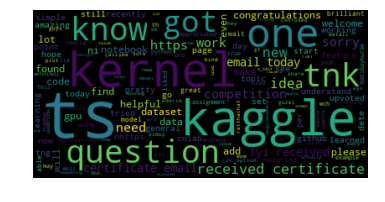

In [17]:
# TODO why do I see thank you?
posts_as_string = sample_post_info\
    .Message\
    .to_string(index=False)

# shouldn't have to do this b/c I removed polite posts earlier
posts_as_string = remove_thanks(posts_as_string)

# Generate a word cloud image
wordcloud = WordCloud().generate(posts_as_string)

# Display the generated image:
# the matplotlib way:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Going forward

Biggest problem: redundent clusters

Possible solutions: 

* Remove very short posts
* Don't include posts on kernels
* Build filter for removing short "thanks!" type posts
* Start w/ sentiment analys & put all very high sentiment posts in a single bin

# Visualization brain storming

Slides on text visualizatoin: https://courses.cs.washington.edu/courses/cse512/15sp/lectures/CSE512-Text.pdf

* Bigram based method, reporting the two terms with the median freuquency
* term saliency, normalize by freq of most common term log(tf_w) / log(tf_the) (and then some sort of regression?)
* Termite-based model: Topics as columns, terms as rows and weight visualiation of term distinctivenes as KL divergence p(T|term)/p(T|any_term)

In [18]:
# next week: get saliency measure by day, 
# look at shift between sliency on day & in corpus as whole pick summary words

In [19]:
# TODO: 
# make sure to match preprocessing (lower cased)
# for each cluster, find the nomralized saliencey measure 
# rank words based on difference in normalizd saliency in whole corpus

# edge cases:
# OOV words, add smoothing or set corpus freq. to 0
# 

In [20]:
frequency_table = pd.read_csv("../input/kaggle-forum-term-frequency-unstemmed/kaggle_lex_freq.csv",
                             error_bad_lines=False)

b'Skipping line 2532: expected 4 fields, saw 5\nSkipping line 2652: expected 4 fields, saw 5\nSkipping line 3490: expected 4 fields, saw 5\nSkipping line 4018: expected 4 fields, saw 5\nSkipping line 4431: expected 4 fields, saw 5\nSkipping line 4857: expected 4 fields, saw 5\nSkipping line 4932: expected 4 fields, saw 5\nSkipping line 5253: expected 4 fields, saw 5\nSkipping line 5390: expected 4 fields, saw 5\nSkipping line 5555: expected 4 fields, saw 6\nSkipping line 5668: expected 4 fields, saw 5\nSkipping line 6678: expected 4 fields, saw 5\nSkipping line 7002: expected 4 fields, saw 5\nSkipping line 7506: expected 4 fields, saw 5\nSkipping line 7533: expected 4 fields, saw 5\nSkipping line 7657: expected 4 fields, saw 5\nSkipping line 7856: expected 4 fields, saw 5\nSkipping line 8253: expected 4 fields, saw 5\nSkipping line 8454: expected 4 fields, saw 5\nSkipping line 8634: expected 4 fields, saw 5\nSkipping line 9229: expected 4 fields, saw 5\nSkipping line 9302: expected 4 f

In [21]:
def get_cluster_saliency_dict(cluster_number):
    # create corpus from a cluster
    text = get_post_info_by_cluster(cluster_number, data = sub_sample, cluster = sub_cluster)\
        .Message.astype(str).str.cat(sep=' ')

    # tokenize
    words = nltk.word_tokenize(text)

    # Remove single-character tokens (mostly punctuation)
    words = [word for word in words if len(word) > 1]

    # Remove numbers
    words = [word for word in words if not word.isnumeric()]

    # remove non-breaking space
    words = [word for word in words if word != "nbsp"]

    # Lowercase all words (default_stopwords are lowercase too)
    words = [word.lower() for word in words]

    # Calculate frequency distribution
    fdist = nltk.FreqDist(words)

    cluster_dict = dict() 

    # get saliency measures
    for word, frequency in fdist.most_common():
        saliency_measure_smoothed = math.log(frequency + 0.0001)/(math.log(fdist.most_common(1)[0][1] + 0.0001))
        cluster_dict[word] = saliency_measure_smoothed
        
    return(cluster_dict, fdist)

In [22]:
def get_surprising_words(cluster_number, frequency_table):
    cluster_dict, fdist = get_cluster_saliency_dict(cluster_number)
    
    words = []
    surprisal = []

    for word, freq in fdist.most_common():
        words.append(word)
        surprisal_measure = cluster_dict[word] - frequency_table.saliency[frequency_table.word == word]
        if surprisal_measure.empty:
            surprisal.append(cluster_dict[word] - .0001)
        else:
            surprisal.append(surprisal_measure.values[0])

    cluster_surprisal_measures = pd.DataFrame(list(zip(words, surprisal)), 
                                              columns =['Words', 'Surprisal']) 

    suprising_words = cluster_surprisal_measures.Words[cluster_surprisal_measures.Surprisal > 0]
    
    return(suprising_words)

In [23]:
get_surprising_words(1, frequency_table)

0             to
2             ''
14      clusters
25     hillshade
26       cluster
57      t-shirts
74           3pm
87          cbam
110    hydrology
116          -60
Name: Words, dtype: object

In [24]:
get_post_info_by_cluster(1, data = sub_sample, cluster = sub_cluster).Message

16539     I like this idea, but why exclude 'Fare' and '...
45253     It's Legen.... wait for it, wait for it...... ...
104389    Hi, great article. I have one question about t...
159723    Thanks both for jumping in! Totally get the di...
160115    We can do this in excel spreadsheet as well. u...
167929    Hi Faith. In correlation you found positive co...
171458    wow i learned so many new things from your ker...
175059    Hi @ratthachat , as promised, I tried to explo...
216195    Generally, check with the kde plot if it's loo...
216197    Ive been having a lot of the same thoughts rec...
216201    Hi All,\ni am working  on a classification pro...
242751    Welcome @sflow7 😊 \n\nThank you for this impor...
242752    Thank you @mohamedabdullah for your response. ...
528658    Congrats!\nI have question about CBAM. \nThere...
Name: Message, dtype: object

In [25]:
get_surprising_words(0, frequency_table)

1               to
9           kaggle
12             gpu
83             doi
276       reckless
329           add_
426     infraction
554         units-
763    early-birds
897     witch-hunt
Name: Words, dtype: object

In [26]:
get_post_info_by_cluster(0, data = sub_sample, cluster = sub_cluster).Message

13935     Brilliant, thanks! Saved me quite a bit of spa...
135673    How do I know the quesions for A1_Score,A2_Sco...
158046    It didn't stop, it's just that the kaggle kern...
160114    Why we need pandas, python and other staff in ...
160120    As someone who is still pretty new to this kin...
                                ...                        
521485    As far as I know, the preivous 2nd and 3rd pla...
526218    Before calling X5 cheaters you need to provide...
526257    Thanks for finalizing the leaderboard. I am wo...
526261    Thank you for your understanding. Yeah I feel ...
526262    @lanjunyelan I know you will earn many more go...
Name: Message, Length: 80, dtype: object